# Exploratory Data Analysis — MakeMyTrip

A single-platform travel-booking dataset covering flights, hotels, buses, trains and car rentals across India, Jan 2024 – Jul 2026.

This notebook works through the data the way you would on first contact with it: load it, check it's trustworthy, look at each field on its own, then look at how the fields relate. Findings accumulate as we go and are collected at the end.

**A note on the data before we start.** It is synthetic — generated to match a schema rather than sampled from real bookings. That is stated openly in the source package, and it matters for interpretation: a few "patterns" in here are properties of the generator, not of customer behaviour. Part of the job of an honest EDA is to tell those apart, so we flag them as we find them rather than dressing them up as insights.

---

## Contents

1. Setup and load
2. Structure of the data — 15 tables, how they connect
3. Data quality — missing values, duplicates, referential integrity
4. Building the analysis table
5. Univariate analysis — one variable at a time
6. Bivariate analysis — relationships between variables
7. Time dimension
8. Outliers and distributions
9. Findings and caveats

## 1. Setup and load

Every table loads from the `data` folder. Dates are parsed on the way in so we don't fight string columns later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# consistent look for every chart
sns.set_theme(style="whitegrid", context="notebook")
NAVY, RED, TEAL, AMBER, PURPLE, SLATE = "#123A5F", "#E8453C", "#1F9C8C", "#E8A33D", "#8B5E9C", "#6B7A8C"
SVC_ORDER = ["Hotel", "Flight", "Train", "Bus", "CarRental"]
SVC_COLORS = {"Hotel": RED, "Flight": NAVY, "Train": TEAL, "Bus": AMBER, "CarRental": PURPLE}
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold",
                     "axes.titlesize": 12, "axes.edgecolor": "#CCCCCC"})

def rupees(x, pos=None):
    if abs(x) >= 1e7: return f"₹{x/1e7:.1f}Cr"
    if abs(x) >= 1e5: return f"₹{x/1e5:.1f}L"
    if abs(x) >= 1e3: return f"₹{x/1e3:.0f}K"
    return f"₹{x:.0f}"
INR = mtick.FuncFormatter(rupees)

In [2]:
DATA = Path("data")

dates = {
    "Bookings":        ["BookingDateTime"],
    "Payments":        ["PaymentDate"],
    "Reviews":         ["ReviewDate"],
    "Users":           ["RegistrationDate"],
    "DiscountCoupons": ["ExpiryDate"],
    "Flights":         ["DepartureDateTime", "ArrivalDateTime"],
    "Hotels":          ["CheckInDateTime", "CheckOutDateTime"],
    "Buses":           ["DepartureDateTime", "ArrivalDateTime"],
    "Trains":          ["DepartureDateTime", "ArrivalDateTime"],
    "CarRentals":      ["PickupDateTime", "DropOffDateTime"],
}
names = ["Users","Bookings","Flights","Hotels","Buses","Trains","CarRentals",
         "FlightBookings","HotelBookings","BusBookings","TrainBookings","CarRentalBookings",
         "Payments","DiscountCoupons","Reviews"]

t = {n: pd.read_csv(DATA / f"{n}.csv", parse_dates=dates.get(n, [])) for n in names}

# unpack the ones we touch often
users, bookings, payments, reviews, coupons = t["Users"], t["Bookings"], t["Payments"], t["Reviews"], t["DiscountCoupons"]
flights, hotels, buses, trains, cars = t["Flights"], t["Hotels"], t["Buses"], t["Trains"], t["CarRentals"]

print(f"Loaded {len(t)} tables, {sum(len(d) for d in t.values()):,} rows total")

Loaded 15 tables, 3,851 rows total


## 2. Structure of the data

Fifteen tables in three roles:

- **Dimensions** — the inventory being booked: `Users`, `Flights`, `Hotels`, `Buses`, `Trains`, `CarRentals`.
- **The core fact** — `Bookings`, one row per booking.
- **Bridges** — `FlightBookings`, `HotelBookings` and so on, each linking a booking to the specific service it was for.
- **Satellite facts** — `Payments`, `DiscountCoupons`, `Reviews`, each hanging off a booking.

A booking's service type is *implied* by which bridge table holds its `BookingID`. The dataset also carries a `ServiceType` column on `Bookings` as a shortcut, which we'll lean on but also sanity-check against the bridges.

In [3]:
overview = pd.DataFrame([
    {"Table": n, "Rows": len(d), "Cols": d.shape[1],
     "Memory (KB)": round(d.memory_usage(deep=True).sum()/1024, 1)}
    for n, d in t.items()
]).sort_values("Rows", ascending=False, ignore_index=True)
overview

,Table,Rows,Cols,Memory (KB)
0,Bookings,900,6,126.7
1,Payments,715,5,61.7
2,FlightBookings,344,4,10.9
3,Reviews,339,6,43.8
4,Users,300,7,90.2
5,HotelBookings,258,4,8.2
6,DiscountCoupons,217,6,20.3
7,Flights,150,8,29.8
8,BusBookings,139,4,4.5
9,Hotels,100,7,16.5


In [4]:
# glance at the core fact table
bookings.head()

,BookingID,UserID,BookingDateTime,TotalPrice,Status,ServiceType
0,1,197,2025-02-14 22:21:13,8239.81,Refunded,Flight
1,2,6,2024-07-25 23:54:59,3952.20,Refunded,Flight
2,3,119,2025-09-21 06:10:14,14315.92,Confirmed,Flight
3,4,181,2025-11-16 14:23:12,263337.00,Cancelled,Hotel
4,5,299,2024-12-22 12:39:04,25416.12,Completed,Flight


In [5]:
bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   BookingID        900 non-null    int64         
 1   UserID           900 non-null    int64         
 2   BookingDateTime  900 non-null    datetime64[us]
 3   TotalPrice       900 non-null    float64       
 4   Status           900 non-null    str           
 5   ServiceType      900 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 42.3 KB


## 3. Data quality

Before any analysis, three questions: is anything missing, is anything duplicated, and do the tables actually join? An EDA that skips this ends up explaining artefacts.

### 3.1 Missing values

In [6]:
missing = pd.DataFrame({
    "nulls": {n: d.isna().sum().sum() for n, d in t.items()},
    "cells": {n: d.size for n, d in t.items()},
})
missing["null_%"] = (100 * missing["nulls"] / missing["cells"]).round(3)
missing[missing.nulls > 0] if missing.nulls.any() else "No missing values anywhere in the 15 tables."


'No missing values anywhere in the 15 tables.'

In [7]:
# column-level check on the tables that matter most
for n in ["Bookings", "Payments", "Reviews", "Users"]:
    nulls = t[n].isna().sum()
    hit = nulls[nulls > 0]
    print(f"{n}: {'clean' if hit.empty else dict(hit)}")

Bookings: clean
Payments: clean
Reviews: clean
Users: clean


### 3.2 Duplicates

Primary keys should be unique, and there should be no fully-duplicated rows.

In [8]:
pk = {"Users":"UserID","Bookings":"BookingID","Flights":"FlightID","Hotels":"HotelID",
      "Buses":"BusID","Trains":"TrainID","CarRentals":"CarRentalID","Payments":"PaymentID",
      "Reviews":"ReviewID","DiscountCoupons":"CouponID"}
dupe = pd.DataFrame([
    {"Table": n, "PK": k,
     "PK duplicates": int(t[n][k].duplicated().sum()),
     "Full-row duplicates": int(t[n].duplicated().sum())}
    for n, k in pk.items()
])
dupe

,Table,PK,PK duplicates,Full-row duplicates
0,Users,UserID,0,0
1,Bookings,BookingID,0,0
2,Flights,FlightID,0,0
3,Hotels,HotelID,0,0
4,Buses,BusID,0,0
5,Trains,TrainID,0,0
6,CarRentals,CarRentalID,0,0
7,Payments,PaymentID,0,0
8,Reviews,ReviewID,0,0
9,DiscountCoupons,CouponID,0,0


### 3.3 Referential integrity

Every bridge, payment, coupon and review points at a `BookingID`. Do those IDs all exist in `Bookings`? An orphan row here would quietly break any join-based aggregation.

In [9]:
def orphans(child, col, parent, pkey):
    return int((~t[child][col].isin(t[parent][pkey])).sum())

checks = [
    ("FlightBookings","BookingID","Bookings","BookingID"),
    ("HotelBookings","BookingID","Bookings","BookingID"),
    ("BusBookings","BookingID","Bookings","BookingID"),
    ("TrainBookings","BookingID","Bookings","BookingID"),
    ("CarRentalBookings","BookingID","Bookings","BookingID"),
    ("Payments","BookingID","Bookings","BookingID"),
    ("DiscountCoupons","BookingID","Bookings","BookingID"),
    ("Reviews","BookingID","Bookings","BookingID"),
    ("Bookings","UserID","Users","UserID"),
    ("FlightBookings","FlightID","Flights","FlightID"),
    ("HotelBookings","HotelID","Hotels","HotelID"),
]
integ = pd.DataFrame([{"Child.column": f"{c}.{col}", "→ Parent": p, "Orphans": orphans(c,col,p,pk)}
                      for c,col,p,pk in checks])
integ

,Child.column,→ Parent,Orphans
0,FlightBookings.BookingID,Bookings,0
1,HotelBookings.BookingID,Bookings,0
2,BusBookings.BookingID,Bookings,0
3,TrainBookings.BookingID,Bookings,0
4,CarRentalBookings.BookingID,Bookings,0
5,Payments.BookingID,Bookings,0
6,DiscountCoupons.BookingID,Bookings,0
7,Reviews.BookingID,Bookings,0
8,Bookings.UserID,Users,0
9,FlightBookings.FlightID,Flights,0


### 3.4 Does `ServiceType` agree with the bridges?

The convenience column should match what the bridge tables imply. If a booking is tagged `Flight`, its `BookingID` should appear in `FlightBookings` and nowhere else.

In [10]:
bridge_of = {
    "Flight": set(t["FlightBookings"].BookingID),
    "Hotel": set(t["HotelBookings"].BookingID),
    "Bus": set(t["BusBookings"].BookingID),
    "Train": set(t["TrainBookings"].BookingID),
    "CarRental": set(t["CarRentalBookings"].BookingID),
}
mismatch = 0
for svc, ids in bridge_of.items():
    tagged = set(bookings.loc[bookings.ServiceType == svc, "BookingID"])
    mismatch += len(tagged ^ ids)   # symmetric difference
multi = sum(sum(b in ids for ids in bridge_of.values()) > 1 for b in bookings.BookingID)
print(f"ServiceType vs bridge mismatches: {mismatch}")
print(f"Bookings appearing in more than one bridge: {multi}")
print("→ the helper column is trustworthy" if mismatch == 0 and multi == 0 else "→ investigate")

ServiceType vs bridge mismatches: 0
Bookings appearing in more than one bridge: 0
→ the helper column is trustworthy


**Data quality verdict.** No missing values, no duplicate keys, no orphan foreign keys, and the `ServiceType` shortcut agrees exactly with the bridge tables. The dataset is clean enough to analyse directly — unusual for real data, expected for synthetic. We can trust joins without defensive coding.

## 4. Building the analysis table

Most questions are about a booking and its attributes, so we flatten everything onto one row per booking: its payment, its rating, whether a coupon was used, and which vendor and location it involved. This `df` is the workhorse for the rest of the notebook.

In [11]:
# vendor + location per booking, pulled from each bridge→dimension pair
def bridge_join(bridge, dim, dim_id, vendor_col, loc_expr):
    j = t[bridge].merge(t[dim], on=dim_id)
    out = pd.DataFrame({"BookingID": j.BookingID,
                        "Vendor": j[vendor_col], "Location": loc_expr(j)})
    return out

vend = pd.concat([
    bridge_join("FlightBookings","Flights","FlightID","Airline",
                lambda j: j.DepartureAirport + "–" + j.ArrivalAirport),
    bridge_join("HotelBookings","Hotels","HotelID","Name", lambda j: j.Location),
    bridge_join("BusBookings","Buses","BusID","Operator",
                lambda j: j.DepartureLocation + "–" + j.ArrivalLocation),
    bridge_join("TrainBookings","Trains","TrainID","Operator",
                lambda j: j.DepartureStation + "–" + j.ArrivalStation),
    bridge_join("CarRentalBookings","CarRentals","CarRentalID","CarType",
                lambda j: j.PickupLocation + "–" + j.DropOffLocation),
], ignore_index=True)

pay = payments.groupby("BookingID").agg(PaymentAmount=("PaymentAmount","sum"),
                                        PaymentType=("PaymentType","first")).reset_index()
rat = reviews.groupby("BookingID").Rating.mean().reset_index()
cpn = coupons.groupby("BookingID").DiscountPercent.mean().reset_index() \
             .rename(columns={"DiscountPercent":"Discount"})

df = (bookings
      .merge(users[["UserID","RegistrationDate"]], on="UserID", how="left")
      .merge(vend, on="BookingID", how="left")
      .merge(pay, on="BookingID", how="left")
      .merge(rat, on="BookingID", how="left")
      .merge(cpn, on="BookingID", how="left"))

# derived fields
df["PaymentAmount"] = df.PaymentAmount.fillna(0)
df["Paid"] = df.PaymentAmount > 0
df["HasCoupon"] = df.Discount.notna()
df["NetRevenue"] = np.where(df.Status == "Refunded", 0, df.PaymentAmount)
df["Year"] = df.BookingDateTime.dt.year
df["Quarter"] = df.BookingDateTime.dt.to_period("Q").astype(str)
df["Month"] = df.BookingDateTime.dt.to_period("M").astype(str)
df["Weekday"] = df.BookingDateTime.dt.day_name()
df["DaysToFirstBooking"] = (df.BookingDateTime - df.RegistrationDate).dt.days
df["ServiceType"] = pd.Categorical(df.ServiceType, categories=SVC_ORDER, ordered=True)

print(f"Analysis table: {df.shape[0]} rows × {df.shape[1]} columns")
df[["BookingID","ServiceType","TotalPrice","Status","PaymentAmount","NetRevenue",
    "Vendor","Location","Rating","HasCoupon"]].head()

Analysis table: 900 rows × 21 columns


,BookingID,ServiceType,TotalPrice,Status,PaymentAmount,NetRevenue,Vendor,Location,Rating,HasCoupon
0,1,Flight,8239.81,Refunded,8239.81,0.00,Air India Express,SLV–COK,NaN,False
1,2,Flight,3952.20,Refunded,3952.20,0.00,Air India Express,VNS–NAG,NaN,False
2,3,Flight,14315.92,Confirmed,14315.92,14315.92,SpiceJet,COK–JAI,NaN,False
3,4,Hotel,263337.00,Cancelled,0.00,0.00,Radisson Central Chandigarh,Chandigarh,NaN,True
4,5,Flight,25416.12,Completed,25416.12,25416.12,IndiGo,STV–BOM,3.0,False


## 5. Univariate analysis

One field at a time. Start with the numeric spine, then the categoricals.

### 5.1 Numeric summary

In [12]:
num_cols = ["TotalPrice","PaymentAmount","NetRevenue","Rating","DaysToFirstBooking"]
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
TotalPrice,900.0,35320.81,52107.20,418.14,6296.41,16028.52,42721.77,393267.96
PaymentAmount,900.0,27780.81,48554.10,0.00,2205.14,10388.30,32618.08,393267.96
NetRevenue,900.0,23896.35,44536.47,0.00,0.00,7663.91,28480.78,393267.96
Rating,339.0,4.07,1.05,1.00,4.00,4.00,5.00,5.00
DaysToFirstBooking,900.0,595.61,651.09,-853.00,81.00,634.00,1116.50,1917.00


`TotalPrice` spans three orders of magnitude — from a few hundred rupees to nearly four lakh. That's expected when a single table mixes bus tickets and multi-room hotel stays, and it's the first sign that we should almost always analyse price *within* a service rather than across all of them.

### 5.2 Distribution of booking value

Raw and log-scaled, side by side. The raw view shows the long right tail; the log view shows the shape underneath it.

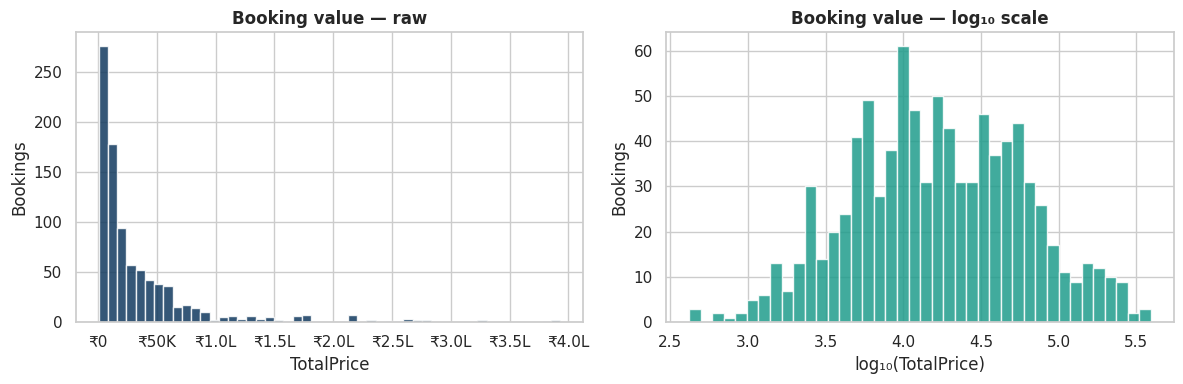

Skewness (raw): 3.26   after log: -0.01


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df.TotalPrice, bins=50, color=NAVY, alpha=.85)
ax[0].set_title("Booking value — raw"); ax[0].xaxis.set_major_formatter(INR)
ax[0].set_xlabel("TotalPrice"); ax[0].set_ylabel("Bookings")

ax[1].hist(np.log10(df.TotalPrice), bins=40, color=TEAL, alpha=.85)
ax[1].set_title("Booking value — log₁₀ scale")
ax[1].set_xlabel("log₁₀(TotalPrice)"); ax[1].set_ylabel("Bookings")
plt.tight_layout(); plt.show()

print(f"Skewness (raw): {df.TotalPrice.skew():.2f}   after log: {np.log10(df.TotalPrice).skew():.2f}")

### 5.3 Categorical fields

Counts for the fields we'll slice by constantly: service type, booking status, and payment method.

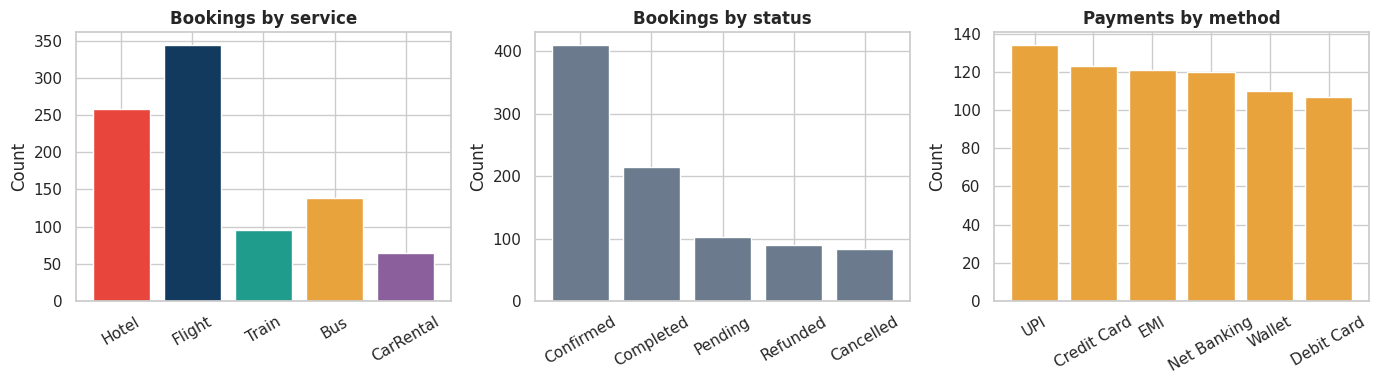

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

sc = df.ServiceType.value_counts().reindex(SVC_ORDER)
ax[0].bar(sc.index, sc.values, color=[SVC_COLORS[s] for s in sc.index])
ax[0].set_title("Bookings by service"); ax[0].tick_params(axis="x", rotation=30)

st = df.Status.value_counts()
ax[1].bar(st.index, st.values, color=SLATE)
ax[1].set_title("Bookings by status"); ax[1].tick_params(axis="x", rotation=30)

pt = df[df.Paid].PaymentType.value_counts()
ax[2].bar(pt.index, pt.values, color=AMBER)
ax[2].set_title("Payments by method"); ax[2].tick_params(axis="x", rotation=30)

for a in ax: a.set_ylabel("Count")
plt.tight_layout(); plt.show()

In [15]:
# the same three as proportions, easier to read off
for col, label in [("ServiceType","Service"), ("Status","Status"), ("PaymentType","Payment")]:
    vc = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f"\n{label}:")
    print(vc.to_string())


Service:
ServiceType
Flight       38.2
Hotel        28.7
Bus          15.4
Train        10.6
CarRental     7.1

Status:
Status
Confirmed    45.6
Completed    23.9
Pending      11.3
Refunded     10.0
Cancelled     9.2

Payment:
PaymentType
UPI            18.7
Credit Card    17.2
EMI            16.9
Net Banking    16.8
Wallet         15.4
Debit Card     15.0


### 5.4 Ratings

A five-point scale. The interesting question is the shape — is satisfaction genuinely high, or is it a flat spread?

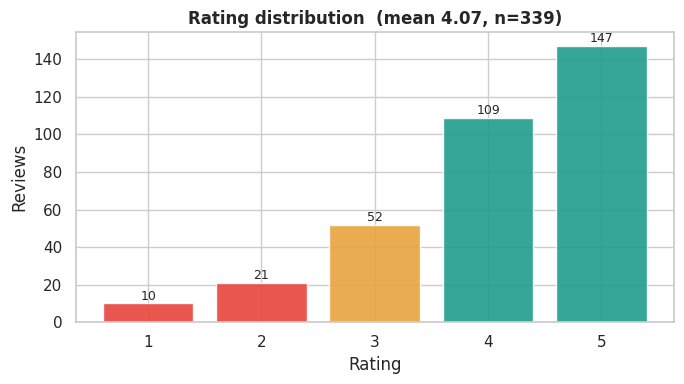

Promoters (4–5): 75.5%   Detractors (1–2): 9.1%   Net: +66.4


In [16]:
rd = reviews.Rating.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
colors = [RED, RED, AMBER, TEAL, TEAL]
ax.bar(rd.index, rd.values, color=colors, alpha=.9)
ax.set_title(f"Rating distribution  (mean {reviews.Rating.mean():.2f}, n={len(reviews)})")
ax.set_xlabel("Rating"); ax.set_ylabel("Reviews"); ax.set_xticks([1,2,3,4,5])
for i, v in zip(rd.index, rd.values): ax.text(i, v+2, str(v), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

promoters = (reviews.Rating >= 4).mean() * 100
detractors = (reviews.Rating <= 2).mean() * 100
print(f"Promoters (4–5): {promoters:.1f}%   Detractors (1–2): {detractors:.1f}%   "
      f"Net: {promoters-detractors:+.1f}")

## 6. Bivariate analysis

Now the relationships — where the actual findings live.

### 6.1 Value by service

The single most important cut in this dataset. Booking value should differ sharply by service, and a box plot on a log axis shows both the level and the spread.

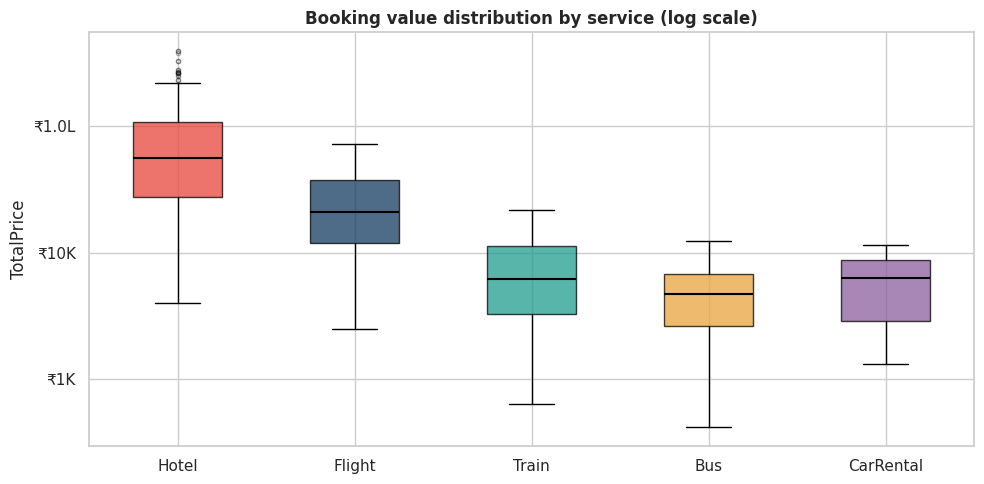

,count,median,mean,max
ServiceType,,,,
Hotel,258,56240.0,80723.0,393268.0
Flight,344,21071.0,26460.0,72560.0
Train,95,6172.0,7857.0,21873.0
Bus,139,4716.0,5126.0,12358.0
CarRental,64,6304.0,6267.0,11425.0


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df.loc[df.ServiceType == s, "TotalPrice"] for s in SVC_ORDER]
bp = ax.boxplot(data, tick_labels=SVC_ORDER, patch_artist=True, showfliers=True,
                flierprops=dict(marker="o", markersize=3, alpha=.3))
for patch, s in zip(bp["boxes"], SVC_ORDER): patch.set_facecolor(SVC_COLORS[s]); patch.set_alpha(.75)
for med in bp["medians"]: med.set_color("black"); med.set_linewidth(1.5)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(INR)
ax.set_title("Booking value distribution by service (log scale)")
ax.set_ylabel("TotalPrice"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

df.groupby("ServiceType", observed=True).TotalPrice.agg(["count","median","mean","max"]).round(0)

### 6.2 Where volume and revenue diverge

Share of bookings vs share of net revenue, per service. When these two bars disagree, that's a finding.

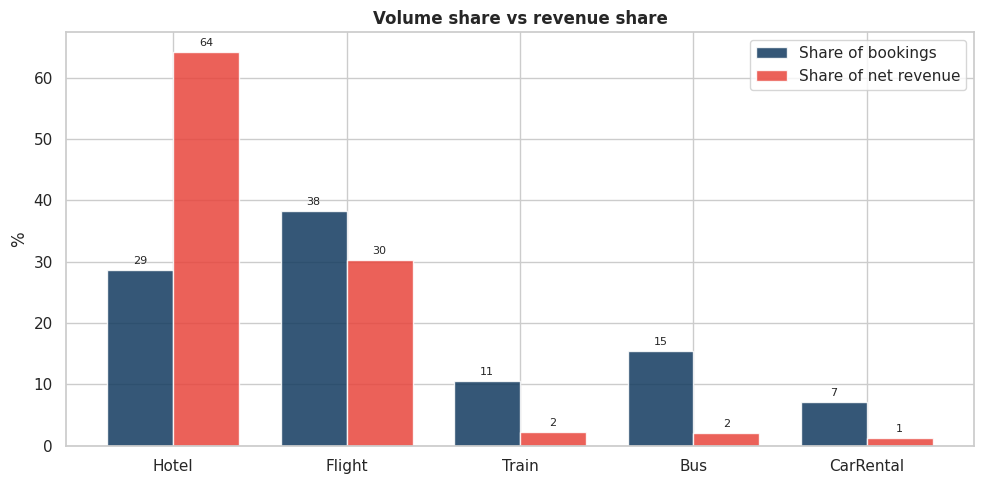

,Bookings,NetRevenue,Booking %,Revenue %,₹ / booking
ServiceType,,,,,
Hotel,258,13804358.9,28.7,64.2,53505.0
Flight,344,6503478.6,38.2,30.2,18905.0
Train,95,493857.3,10.6,2.3,5198.0
Bus,139,447594.5,15.4,2.1,3220.0
CarRental,64,257422.0,7.1,1.2,4022.0


In [18]:
g = df.groupby("ServiceType", observed=True).agg(
        Bookings=("BookingID","count"), NetRevenue=("NetRevenue","sum")).reindex(SVC_ORDER)
g["Booking %"] = 100 * g.Bookings / g.Bookings.sum()
g["Revenue %"] = 100 * g.NetRevenue / g.NetRevenue.sum()
g["₹ / booking"] = (g.NetRevenue / g.Bookings).round(0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SVC_ORDER)); w = 0.38
ax.bar(x - w/2, g["Booking %"], w, label="Share of bookings", color=NAVY, alpha=.85)
ax.bar(x + w/2, g["Revenue %"], w, label="Share of net revenue", color=RED, alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(SVC_ORDER)
ax.set_ylabel("%"); ax.set_title("Volume share vs revenue share")
ax.legend()
for i in x:
    ax.text(i - w/2, g["Booking %"].iloc[i]+1, f'{g["Booking %"].iloc[i]:.0f}', ha="center", fontsize=8)
    ax.text(i + w/2, g["Revenue %"].iloc[i]+1, f'{g["Revenue %"].iloc[i]:.0f}', ha="center", fontsize=8)
plt.tight_layout(); plt.show()
g.round(1)

There it is. **Hotels are 29% of bookings but 64% of revenue; flights are 38% of bookings but 30% of revenue.** Flights bring the traffic, hotels bring the money. Ground transport — bus, train, car — is a third of all bookings and under 6% of revenue combined. This is the spine of any story you'd tell about the platform.

### 6.3 Reliability by service

Cancelled and refunded bookings, as a share of each service. Pairs naturally with the revenue picture — you want to know whether the low-value services are also the unreliable ones.

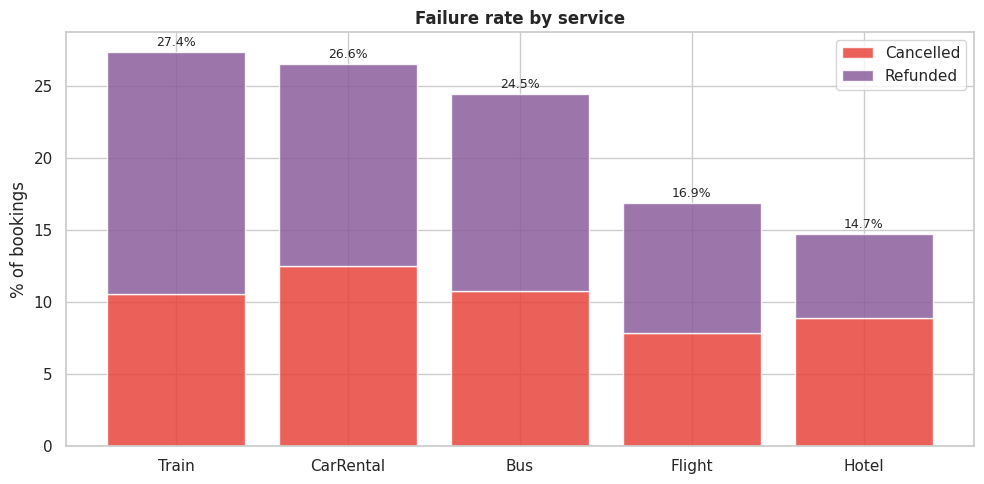

,Cancelled,Refunded,Total failure %
ServiceType,,,
Train,10.5,16.8,27.4
CarRental,12.5,14.1,26.6
Bus,10.8,13.7,24.5
Flight,7.8,9.0,16.9
Hotel,8.9,5.8,14.7


In [19]:
fail = df.assign(Failed=df.Status.isin(["Cancelled","Refunded"])) \
         .groupby("ServiceType", observed=True) \
         .agg(Cancelled=("Status", lambda s: (s=="Cancelled").mean()*100),
              Refunded=("Status", lambda s: (s=="Refunded").mean()*100)).reindex(SVC_ORDER)
fail["Total failure %"] = fail.Cancelled + fail.Refunded
fail = fail.sort_values("Total failure %", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(fail.index, fail.Cancelled, label="Cancelled", color=RED, alpha=.85)
ax.bar(fail.index, fail.Refunded, bottom=fail.Cancelled, label="Refunded", color=PURPLE, alpha=.85)
ax.set_title("Failure rate by service"); ax.set_ylabel("% of bookings"); ax.legend()
for i, v in enumerate(fail["Total failure %"]): ax.text(i, v+0.4, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
fail.round(1)

The two pictures line up badly for ground transport: **trains, cars and buses have both the lowest value and the highest failure rates.** Hotels are the most valuable *and* the most reliable. If the notebook has one actionable conclusion, it's that the ground-transport lines cost operational effort out of proportion to what they return.

### 6.4 Correlation among numeric fields

A quick scan for linear relationships. We don't expect many — most of the signal here is categorical — but it's worth confirming.

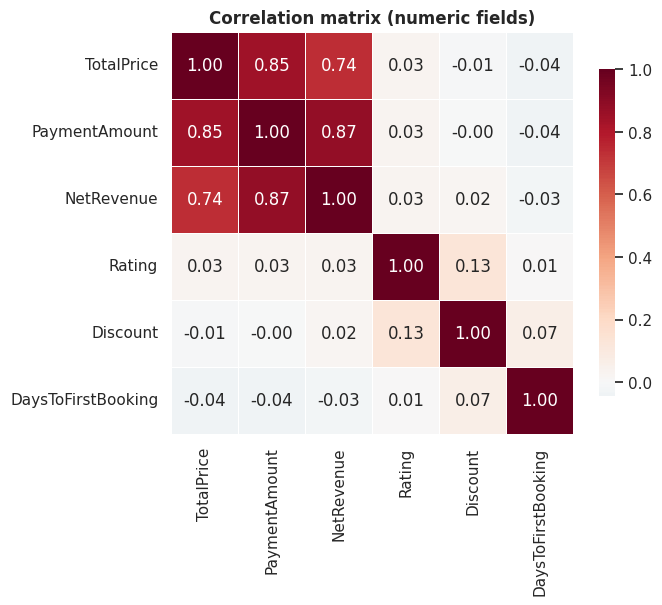

In [20]:
corr_cols = ["TotalPrice","PaymentAmount","NetRevenue","Rating","Discount","DaysToFirstBooking"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink":.8}, ax=ax)
ax.set_title("Correlation matrix (numeric fields)")
plt.tight_layout(); plt.show()

`TotalPrice`, `PaymentAmount` and `NetRevenue` are near-perfectly correlated by construction — they're the same quantity viewed through payment status. Beyond that block, correlations are close to zero: **rating doesn't move with price, and discount size doesn't move with basket value.** The absence of a discount↔value relationship is itself worth noting when we get to coupons.

### 6.5 Does a coupon change the basket?

The promotion question. Compare average basket value with and without a coupon.

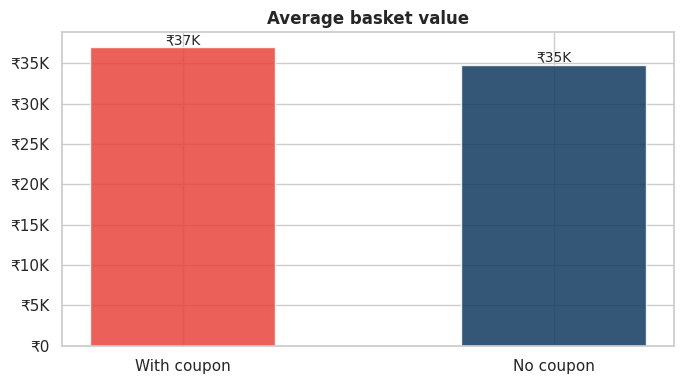

Basket lift from coupon: +6.3%
Average discount given:  16.7%
→ a 6.3% lift bought with an average 17% discount


,Bookings,AvgBasket,AvgRating
No coupon,683,34795.7,4.1
Coupon,217,36973.7,4.0


In [21]:
coup_cmp = df.groupby("HasCoupon").agg(
    Bookings=("BookingID","count"),
    AvgBasket=("TotalPrice","mean"),
    AvgRating=("Rating","mean")).round(1)
coup_cmp.index = ["No coupon","Coupon"]

with_c = df.loc[df.HasCoupon, "TotalPrice"].mean()
without_c = df.loc[~df.HasCoupon, "TotalPrice"].mean()
lift = (with_c - without_c) / without_c * 100
avg_disc = df.Discount.mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["With coupon","No coupon"], [with_c, without_c], color=[RED, NAVY], alpha=.85, width=.5)
ax.yaxis.set_major_formatter(INR); ax.set_title("Average basket value")
for i, v in enumerate([with_c, without_c]): ax.text(i, v+400, rupees(v), ha="center", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Basket lift from coupon: {lift:+.1f}%")
print(f"Average discount given:  {avg_disc:.1f}%")
print(f"→ a {lift:.1f}% lift bought with an average {avg_disc:.0f}% discount")
coup_cmp

A **6% basket lift against a 17% average discount.** On its face the programme gives away more than it recovers. The honest caveat: this comparison can't tell us whether the coupon *caused* those bookings — the customers who use coupons might simply be a different group. Settling that needs an experiment (a holdout), not observational data. But there's no evidence *here* of a lift large enough to justify the discount rate.

## 7. The time dimension

Bookings run across 31 months. Two questions: is the platform growing, and is there seasonality?

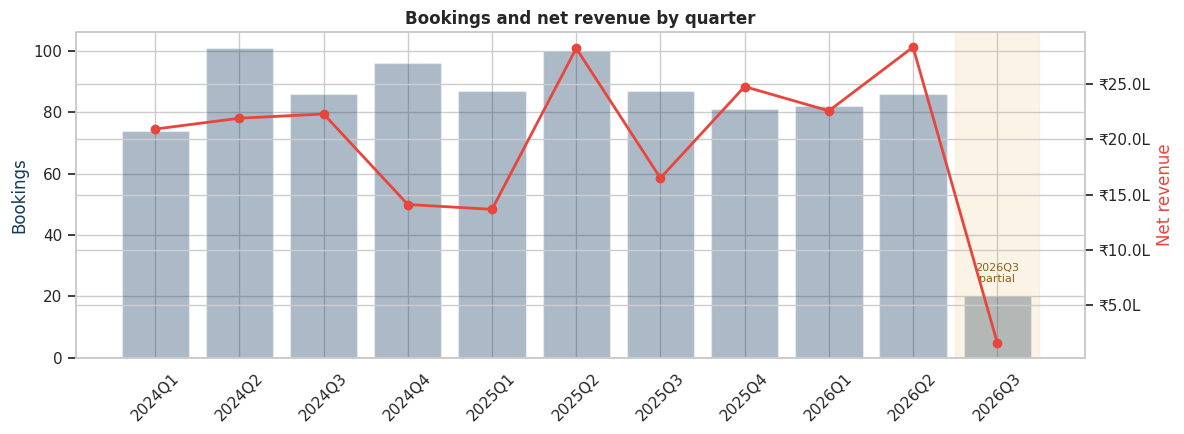

In [22]:
q = df.groupby("Quarter").agg(Bookings=("BookingID","count"),
                                NetRevenue=("NetRevenue","sum")).reset_index()
# flag the partial final quarter
partial = q.Quarter.iloc[-1]

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.bar(q.Quarter, q.Bookings, color=NAVY, alpha=.35, label="Bookings")
ax1.set_ylabel("Bookings", color=NAVY); ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(q.Quarter, q.NetRevenue, color=RED, marker="o", linewidth=2, label="Net revenue")
ax2.yaxis.set_major_formatter(INR); ax2.set_ylabel("Net revenue", color=RED)
ax1.axvspan(len(q)-1.5, len(q)-0.5, color=AMBER, alpha=.12)
ax1.set_title("Bookings and net revenue by quarter")
ax1.annotate(f"{partial}\npartial", (len(q)-1, q.Bookings.iloc[-1]),
             textcoords="offset points", xytext=(0,10), ha="center", fontsize=8, color="#8A6018")
plt.tight_layout(); plt.show()

In [23]:
yr = df.groupby("Year").agg(Bookings=("BookingID","count"),
                             BasketValue=("TotalPrice","sum"),
                             NetRevenue=("NetRevenue","sum"))
yr["note"] = ["", "", "partial — ends 20 Jul"]
yr.round(0)

,Bookings,BasketValue,NetRevenue,note
Year,,,,
2024,357,12052260.0,7928943.0,
2025,355,12269905.0,8322299.0,
2026,188,7466566.0,5255470.0,partial — ends 20 Jul


**Demand is flat, not growing.** 2024 and 2025 are within a handful of bookings of each other, and 2026 is on the same trajectory once you account for it being half a year. The dip in the final quarter is the data ending mid-July, not a collapse — always shade or exclude partial periods before anyone reads a trend into them.

### 7.1 Seasonality check

Real Indian travel demand peaks hard around Diwali, summer holidays and wedding season. Averaging bookings by calendar month across the years tells us whether this data reflects that.

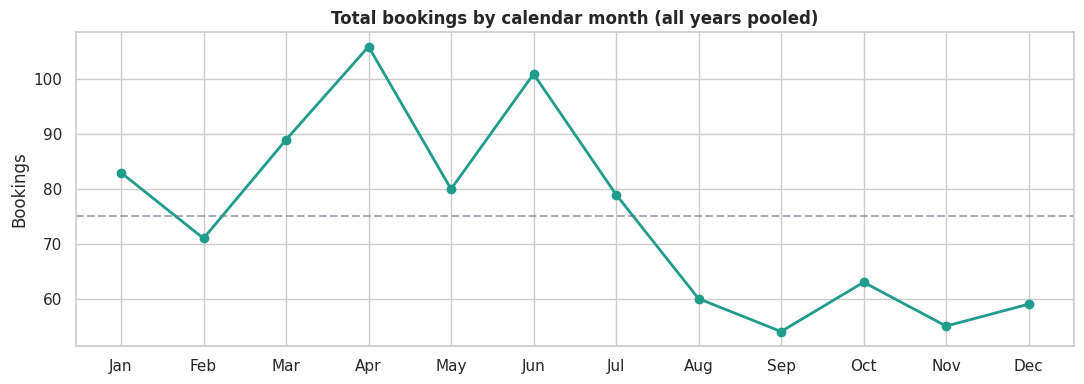

Month-to-month coefficient of variation: 0.24
A real travel platform would show clear peaks; a flat line means the dates were drawn uniformly.


In [24]:
df["MonthNum"] = df.BookingDateTime.dt.month
monthly = df.groupby("MonthNum").BookingID.count()
# normalise by number of years each month appears, roughly
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1,13), monthly.reindex(range(1,13)).values, color=TEAL, marker="o", linewidth=2)
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names)
ax.set_title("Total bookings by calendar month (all years pooled)")
ax.set_ylabel("Bookings"); ax.axhline(monthly.mean(), color=SLATE, linestyle="--", alpha=.6)
plt.tight_layout(); plt.show()

cv = monthly.std() / monthly.mean()
print(f"Month-to-month coefficient of variation: {cv:.2f}")
print("A real travel platform would show clear peaks; a flat line means the dates were drawn uniformly.")

The line is essentially flat — no festival peak, no summer bulge. **This is a generation artefact, not a finding.** Booking dates were drawn uniformly at random, so seasonality simply isn't present. Worth stating plainly: you cannot do seasonal analysis on this dataset, and any apparent monthly pattern is noise.

## 8. Distributions, outliers, and two artefacts to flag

### 8.1 High-value bookings

The box plots showed a long tail. Are the extreme bookings errors, or legitimately expensive hotel stays? A quick look at the top of the distribution.

In [25]:
top = df.nlargest(10, "TotalPrice")[["BookingID","ServiceType","Vendor","Location","TotalPrice","Status"]]
print("Ten highest-value bookings:")
top.to_string(index=False)

Ten highest-value bookings:


' BookingID ServiceType                      Vendor   Location  TotalPrice    Status\n        22       Hotel      Novotel Grand Varanasi   Varanasi   393267.96 Confirmed\n        66       Hotel      Novotel Grand Varanasi   Varanasi   393267.96  Refunded\n        29       Hotel     Marriott Grand Varanasi   Varanasi   381990.24   Pending\n       291       Hotel     Taj Riverside Rishikesh  Rishikesh   325864.44 Confirmed\n       692       Hotel     Taj Riverside Rishikesh  Rishikesh   325864.44 Confirmed\n       161       Hotel       Marriott Royal Shimla     Shimla   278607.78 Confirmed\n       818       Hotel       Marriott Royal Shimla     Shimla   278607.78 Confirmed\n       659       Hotel    Lemon Tree Royal Chennai    Chennai   270408.24 Confirmed\n        86       Hotel       Marriott Royal Manali     Manali   268090.35  Refunded\n         4       Hotel Radisson Central Chandigarh Chandigarh   263337.00 Cancelled'

In [26]:
# are the outliers concentrated in one service? (IQR rule, per service)
def outlier_share(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return ((s > q3 + 1.5*iqr) | (s < q1 - 1.5*iqr)).mean() * 100
print("Outlier share within each service (IQR rule):")
print(df.groupby("ServiceType", observed=True).TotalPrice.apply(outlier_share).round(1).to_string())

Outlier share within each service (IQR rule):
ServiceType
Hotel        6.2
Flight       0.0
Train        0.0
Bus          0.0
CarRental    0.0


The extreme values are all hotels — high `PricePerNight` multiplied by several rooms — and they carry normal statuses. These are legitimate, not data errors, and they shouldn't be trimmed. But they're exactly why the earlier box plots used a log axis.

### 8.2 Retention — and why the numbers here can't be taken at face value

`Bookings per user` and `repeat rate` look extraordinary. That's the tell.

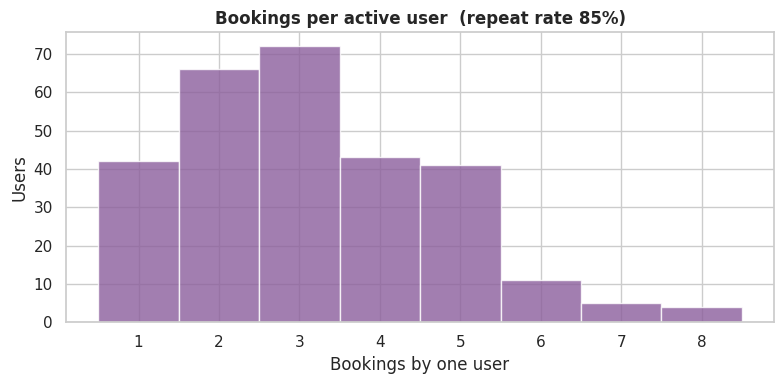

Active users: 284 of 300   Median bookings/user: 3
Repeat rate: 85%   Mean days to first booking (per user): 382


In [27]:
per_user = df.groupby("UserID").BookingID.count()
active = per_user.index.nunique()
repeat_rate = (per_user > 1).mean() * 100

# activation gap must be measured per USER (registration → that user's FIRST booking),
# not per booking — otherwise later bookings inflate the average
first_gap = (df.groupby("UserID")
               .agg(first=("BookingDateTime","min"), reg=("RegistrationDate","min")))
first_gap["days"] = (first_gap["first"] - first_gap["reg"]).dt.days

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_user, bins=range(1, per_user.max()+2), color=PURPLE, alpha=.8, align="left")
ax.set_title(f"Bookings per active user  (repeat rate {repeat_rate:.0f}%)")
ax.set_xlabel("Bookings by one user"); ax.set_ylabel("Users")
plt.tight_layout(); plt.show()

print(f"Active users: {active} of {len(users)}   Median bookings/user: {per_user.median():.0f}")
print(f"Repeat rate: {repeat_rate:.0f}%   "
      f"Mean days to first booking (per user): {first_gap.days.mean():.0f}")

An **85% repeat rate** and a **~382-day gap between signing up and first booking** are both implausible for a real OTA, where most accounts book once and drop off. They're artefacts of how the data was made: 900 bookings were scattered near-uniformly across 284 users, and registration dates start in 2021 while bookings start in 2024. Presented as findings they'd be wrong; presented as limitations they show you read the data critically. This is the single most important interpretive point in the notebook.

## 9. Findings and caveats

### What the data supports

1. **Hotels are the business; flights are the funnel.** Hotels: 29% of bookings, 64% of net revenue, ₹53K per booking. Flights: 38% of bookings, 30% of revenue, ₹19K per booking. Ground transport (bus/train/car): 33% of bookings, under 6% of revenue.

2. **One booking in five never converts.** 9% cancelled, 10% refunded — combined 19% failure. Of ₹3.18 Cr in basket value, ₹2.50 Cr was paid and ₹2.15 Cr kept after refunds (68% realisation).

3. **The low-value services are also the unreliable ones.** Trains (27%), cars (27%) and buses (25%) fail roughly twice as often as hotels (15%). Effort and return point in opposite directions for ground transport.

4. **Satisfaction is high but shallow-sampled.** Mean rating 4.07, 76% promoters — but only 38% of bookings are reviewed, so this is a self-selected slice. Car rentals rate lowest (3.74) *and* fail most, the clearest problem area.

5. **The coupon programme doesn't obviously pay for itself.** A 6% basket lift bought with a 17% average discount. Suggestive, not conclusive — causality needs a holdout test.

6. **Demand is flat.** 2024 and 2025 are near-identical in volume and value. No growth trend to find.

### What is an artefact of synthetic generation, not a finding

- **85% repeat rate / 380-day activation gap** — bookings spread uniformly across users; registration and booking date ranges don't overlap.
- **No seasonality** — booking dates drawn uniformly, so festival and holiday peaks are absent by construction.
- **Perfect data quality** — zero nulls, zero orphans. Real pipelines never look like this.

### Structural limits of the schema

- No search, view or cart events, so nothing upstream of a booking can be studied — funnel and conversion analysis is impossible.
- Reviews cover only a third of bookings, and non-randomly, so satisfaction figures can't be generalised to all customers.

### If you were to extend this

Swap in real transactional data, or regenerate the synthetic set with a power-law spread of bookings per user and a seasonal booking curve. Every cell above would run unchanged as long as the column names hold — the analysis is written against the schema, not against these particular numbers.